<a href="https://colab.research.google.com/github/lalipedrozo/PUC_MVP_Analise_de_Dados/blob/main/PUC_MVP_Analise_de_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Larissa de Almeida Leite Pedrozo

**Matrícula:** 4052025002512

**Dataset:** [Gold Price: (2005-2026) Historical Price Data](https://www.kaggle.com/datasets/bhushandivekar/gold-price-2005-2026-historical-price-data)

# Descrição do Problema

O conjunto de dados utilizado contém informações históricas sobre o preço do ouro (Gold Futures), incluindo variáveis como preço de fechamento, abertura, máxima, mínima, volume negociado e variação percentual diária.
O objetivo deste projeto é analisar o comportamento dessas variáveis ao longo do tempo e desenvolver um modelo preditivo capaz de antecipar a direção do preço do ouro no período seguinte (alta ou queda), com base em informações históricas.
Para isso, são utilizadas técnicas de análise exploratória de dados e modelagem preditiva, com foco na identificação de padrões e relações entre as variáveis. Trata-se de um problema de classificação binária, utilizando variáveis derivadas de séries temporais.

## Hipóteses do Problema

As hipóteses consideradas para este projeto são as seguintes:
1. As variáveis de preço (abertura, fechamento, máxima e mínima) apresentam forte correlação entre si?
2. A variação percentual diária (retorno) apresenta distribuição concentrada próxima de zero, com presença de valores extremos (outliers)?
3. Variáveis derivadas, como retornos, médias móveis e volatilidade, possuem poder preditivo sobre a direção futura do preço do ouro?

## Tipo de Problema

Este é um problema de classificação supervisionada binária aplicado a séries temporais. A partir de variáveis derivadas de dados históricos do preço do ouro, o objetivo é prever a direção do preço no período seguinte, classificando-o como alta ou queda.

## Seleção de Dados

O dataset utilizado neste projeto foi obtido a partir da plataforma Kaggle, contendo dados históricos do preço do ouro (Gold Futures).
Trata-se de um conjunto de dados estruturado, com informações relevantes para análise financeira, como preços de abertura, fechamento, máxima, mínima, volume negociado e variação percentual diária.
O dataset foi escolhido por sua relevância no contexto financeiro e por permitir a aplicação de técnicas de análise de séries temporais.
Não foi necessária uma etapa adicional de seleção de dados, uma vez que os dados já se encontravam organizados e adequados para análise exploratória e modelagem preditiva.

## Atributos do Dataset

O dataset utilizado contém 4.997 observações de dados históricos do preço do ouro (Gold Futures), com os seguintes atributos:

*   Date: data da negociação
*   Price: preço de fechamento diário do ouro (USD)
*   Open: preço de abertura do dia
*   High: preço máximo do dia
*   Low: preço mínimo do dia
*   Vol.: volume negociado (número de contratos)
*   Change %: variação percentual do preço em relação ao dia anterior

Adicionalmente, foram criadas variáveis derivadas para auxiliar na modelagem, como retorno diário, médias móveis e volatilidade.

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Iris.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
# Upload dataset
url = "https://raw.githubusercontent.com/lalipedrozo/PUC_MVP_Analise_de_Dados/refs/heads/main/data/Gold%20Futures%20Historical%20Data.csv"

df = pd.read_csv(url)

display(df.head())

,Date,Price,Open,High,Low,Vol.,Change %
0,01-03-2005,429.7,438.9,438.9,427.8,82850,-1.98
1,01-04-2005,429.2,430.4,431.3,424.8,54830,-0.12
2,01-05-2005,427.3,429,429.3,425.9,43720,-0.44
3,01-06-2005,421.6,427,428.3,421.1,65180,-1.33
4,01-07-2005,419.5,422.1,425.8,417.2,97970,-0.50


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4997 entries, 0 to 4996
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      4997 non-null   object 
 1   Price     4997 non-null   object 
 2   Open      4997 non-null   object 
 3   High      4997 non-null   object 
 4   Low       4997 non-null   object 
 5   Vol.      4997 non-null   int64  
 6   Change %  4997 non-null   float64
dtypes: float64(1), int64(1), object(5)
memory usage: 273.4+ KB


#Limpeza e Tratamento de Dados

In [6]:
# Converter data
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=False)

# Colunas numéricas que vieram como texto
price_cols = ['Price', 'Open', 'High', 'Low']

for col in price_cols:
    df[col] = (
        df[col]
        .str.replace(',', '', regex=False)   # remove separador de milhar
        .astype(float)
    )
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4997 entries, 0 to 4996
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      4997 non-null   datetime64[ns]
 1   Price     4997 non-null   float64       
 2   Open      4997 non-null   float64       
 3   High      4997 non-null   float64       
 4   Low       4997 non-null   float64       
 5   Vol.      4997 non-null   int64         
 6   Change %  4997 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 273.4 KB


In [7]:
# Check de duplicatas em linhas
df.duplicated().sum()

np.int64(0)

# Análise de Dados

Nesta etapa de Análise Exploratória de Dados (EDA) sobre o dataset de preços do ouro, buscamos compreender a distribuição, as relações e o comportamento das variáveis ao longo do tempo. Essa análise é fundamental para orientar as etapas subsequentes de pré-processamento e modelagem, permitindo identificar padrões, correlações e possíveis anomalias nos dados.

## Total e Tipo das Instâncias

O dataset utilizado possui 4.997 instâncias (observações), representando dados históricos do preço do ouro ao longo do tempo.
As variáveis de preço (Price, Open, High, Low) são do tipo numérico (float), assim como a variável de variação percentual (Change %). A variável de volume (Vol.) é do tipo numérico inteiro (int), enquanto a variável de data (Date) foi convertida para o formato de data (datetime).
Adicionalmente, foram criadas variáveis derivadas numéricas, como retorno diário, médias móveis e volatilidade, utilizadas na etapa de modelagem.

In [13]:
# Dimensão do dataset
print("Shape do dataset:", df.shape)

# Tipos das variáveis
df.info()

Shape do dataset: (4997, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4997 entries, 0 to 4996
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      4997 non-null   datetime64[ns]
 1   Price     4997 non-null   float64       
 2   Open      4997 non-null   float64       
 3   High      4997 non-null   float64       
 4   Low       4997 non-null   float64       
 5   Vol.      4997 non-null   int64         
 6   Change %  4997 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 273.4 KB


O dataset possui 4997 linhas e 7 colunas.
As variáveis presentes incluem dados de data, preço (abertura, fechamento, máxima e mínima), volume e variação percentual.

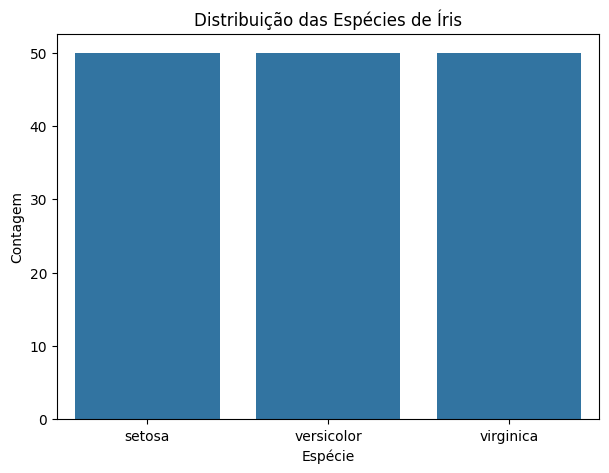

In [ ]:
plt.figure(figsize=(7, 5))
# gráfico de barras simples
sns.countplot(x='species', data=df)
plt.title('Distribuição das Espécies de Íris')
plt.xlabel('Espécie')
plt.ylabel('Contagem')
plt.show()

O gráfico de barras mostra que cada espécie de Íris (setosa, versicolor, virginica) possui 50 amostras, confirmando que o dataset é balanceado em termos de classes.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [25]:
# estatísticas descritivas básicas do dataset
df.describe()

,Date,Price,Open,High,Low,Vol.,Change %,Log_Vol
count,4997,4997.000000,4997.000000,4997.000000,4997.000000,4997.000000,4997.000000,4997.000000
mean,2015-02-25 10:38:00.888532992,1432.825371,1432.636692,1444.205517,1420.722848,158789.447669,0.056192,-inf
min,2005-01-03 00:00:00,414.300000,414.000000,415.300000,411.500000,0.000000,-11.390000,-inf
25%,2009-12-10 00:00:00,1075.200000,1072.200000,1081.400000,1065.700000,94790.000000,-0.500000,11.459419
50%,2014-11-25 00:00:00,1302.700000,1303.000000,1310.800000,1293.200000,150240.000000,0.050000,11.919989
75%,2020-06-08 00:00:00,1739.900000,1738.900000,1752.600000,1724.400000,209910.000000,0.670000,12.254434
max,2026-02-24 00:00:00,5354.800000,5449.900000,5626.800000,5175.000000,816530.000000,8.970000,13.612819
std,NaN,702.579377,701.866930,709.571309,694.697707,98813.012007,1.176873,NaN


### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

In [26]:
# média dos atributos numéricos do dataset
df.describe().loc['mean', :]

,mean
Date,2015-02-25 10:38:00.888532992
Price,1432.825371
Open,1432.636692
High,1444.205517
Low,1420.722848
Vol.,158789.447669
Change %,0.056192
Log_Vol,-inf


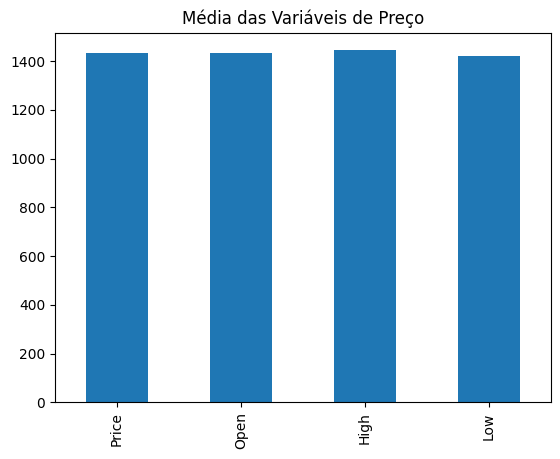

np.float64(158789.44766860115)

In [31]:
# Qual gráfico seria interessante usar pra mostrar a média?
df[['Price','Open','High','Low']].mean().plot(kind='bar')
plt.title('Média das Variáveis de Preço')
plt.show()

# gráfico 2: volume
df['Vol.'].mean()

As variáveis de preço (abertura, fechamento, máxima e mínima) apresentam médias bastante próximas entre si. Isso ocorre porque representam diferentes pontos do preço do ativo ao longo do mesmo dia, sendo naturalmente correlacionadas.
Já a variável de volume apresenta ordem de grandeza distinta, refletindo a quantidade de contratos negociados.

### Desvio Padrão

O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

In [44]:
# desvio padrão dos atributos numéricos do dataset
df.describe().loc['std']
df.std(numeric_only=True)

,0
Price,702.579377
Open,701.866930
High,709.571309
Low,694.697707
Change %,1.176873


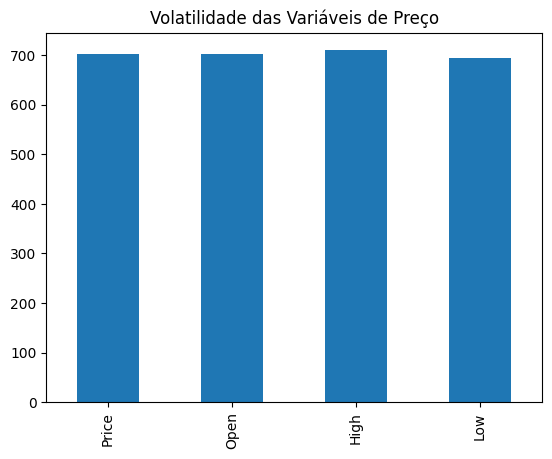

Desvio padrão do Volume: 98813.01200737015


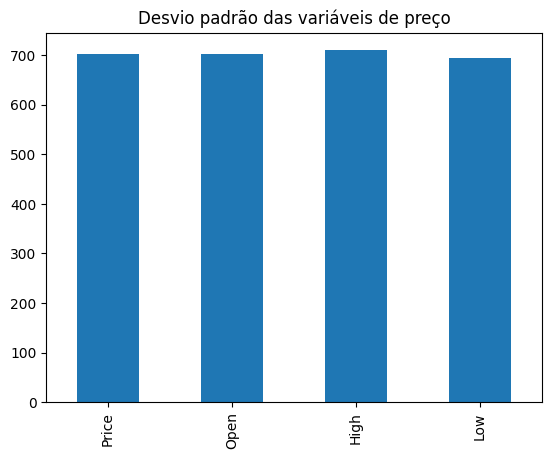

In [45]:
# Qual gráfico seria interessante usar pra mostrar o desvio padrão?

# preços
df[['Price','Open','High','Low']].std().plot(kind='bar')
plt.title('Volatilidade das Variáveis de Preço')
plt.show()

# volume separado
print("Desvio padrão do Volume:", df['Vol.'].std())

Nota-se que as variáveis de preço apresentam níveis de dispersão semelhantes, refletindo sua forte correlação.
Já a variável de variação percentual apresenta menor magnitude, mas é relevante para capturar a volatilidade relativa do ativo.

## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

### *change %*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

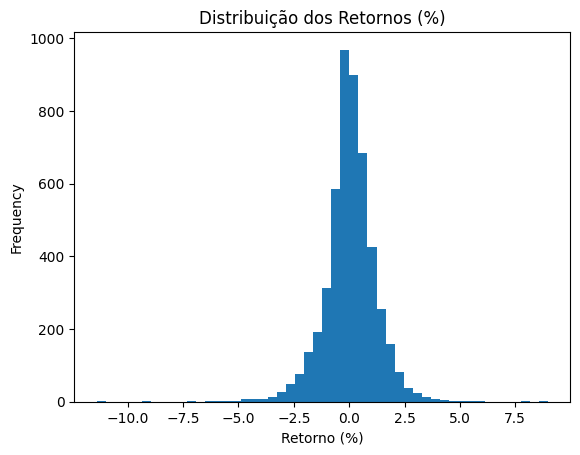

In [49]:
# Histograma do comprimento da sépala (um dos atributos)
df['Change %'].plot(kind='hist', bins=50)
plt.title('Distribuição dos Retornos (%)')
plt.xlabel('Retorno (%)')
plt.show()

A distribuição dos retornos apresenta concentração em torno de zero, indicando que a maior parte das variações diárias é pequena. Observa-se também a presença de caudas, sugerindo a ocorrência de eventos extremos.

> Adicionar aspas



### *price*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

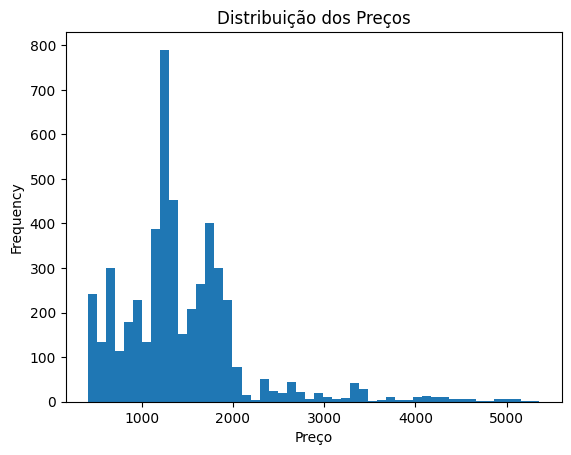

In [50]:
df['Price'].plot(kind='hist', bins=50)
plt.title('Distribuição dos Preços')
plt.xlabel('Preço')
plt.show()

A distribuição dos preços não é simétrica, refletindo a tendência de crescimento do ouro ao longo do tempo. Isso indica que a série não é estacionária.

Para análise estatística, a variável de retorno (Change %) é mais adequada que o preço, pois apresenta comportamento mais próximo de estacionariedade.

## Boxplot

Para entender as diferenças entre as espécies, devemos olhar como se comportam os valores quando agrupadas por espécie. Isso nos permite comparar a média, mediana e desvio padrão de cada característica para Iris setosa, Iris versicolor e Iris virginica, além de visualizar suas distribuições por meio de boxplots.


In [ ]:
# Estatísticas descritivas agrupadas por espécie
df.groupby('species').describe()

sepal length (cm)                                              \
                       count   mean       std  min    25%  50%  75%  max   
species                                                                    
setosa                  50.0  5.006  0.352490  4.3  4.800  5.0  5.2  5.8   
versicolor              50.0  5.936  0.516171  4.9  5.600  5.9  6.3  7.0   
virginica               50.0  6.588  0.635880  4.9  6.225  6.5  6.9  7.9   

           sepal width (cm)         ... petal length (cm)       \
                      count   mean  ...               75%  max   
species                             ...                          
setosa                 50.0  3.428  ...             1.575  1.9   
versicolor             50.0  2.770  ...             4.600  5.1   
virginica              50.0  2.974  ...             5.875  6.9   

           petal width (cm)                                            
                      count   mean       std  min  25%  50%  75%  max  
species                                                                
setosa                 50.0  0.246  0.105386  0.1  0.2  0.2  0.3  0.6  
versicolor             50.0  1.326  0.197753  1.0  1.2  1.3  1.5  1.8  
virginica              50.0  2.026  0.274650  1.4  1.8  2.0  2.3  2.5  

[3 rows x 32 columns]

Como o dataset não possui variáveis categóricas, optou-se por analisar diretamente a distribuição das variáveis numéricas.

### *variáveis de preço*

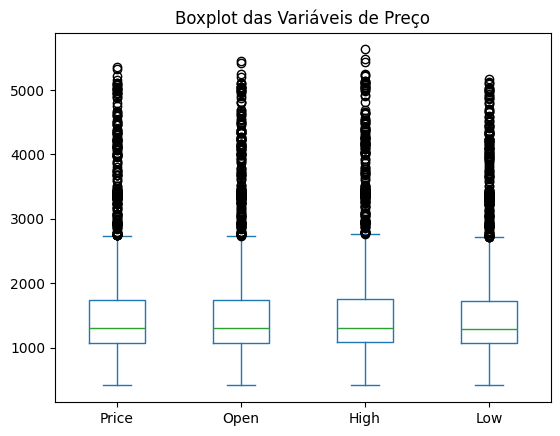

In [51]:
#Boxplot das variáveis de preço
df[['Price','Open','High','Low']].plot(kind='box')
plt.title('Boxplot das Variáveis de Preço')
plt.show()

O boxplot evidencia a distribuição das variáveis de preço, bem como a presença de possíveis outliers. Observa-se comportamento semelhante entre as variáveis, reforçando a forte correlação entre elas.

### *retorno*

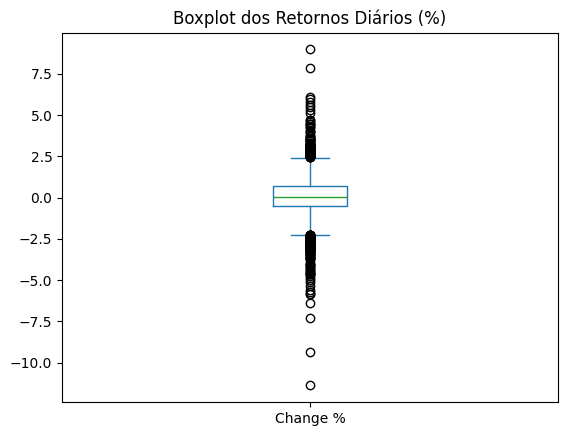

In [59]:
#Boxplot dos retornos diários (%)
df['Change %'].plot(kind='box')
plt.title('Boxplot dos Retornos Diários (%)')
plt.show()

O boxplot dos retornos evidencia a presença de outliers, indicando dias com variações atípicas no preço do ouro. Esse comportamento é comum em séries financeiras, que apresentam eventos extremos ocasionais.

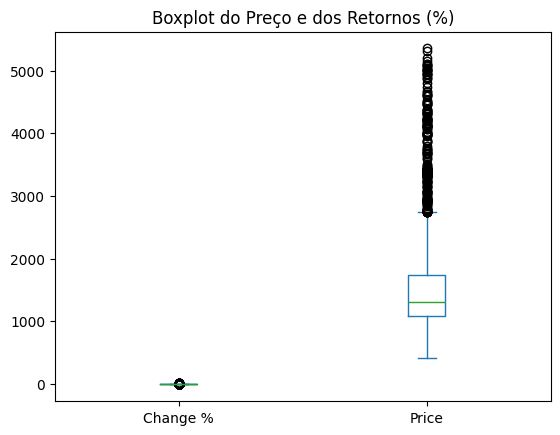

In [54]:
df[['Change %','Price']].plot(kind='box')
plt.title('Boxplot do Preço e dos Retornos Diários (%)')
plt.show()

As variáveis apresentam escalas distintas, o que impacta a visualização conjunta no boxplot.

Nota-se que os retornos estão concentrados próximos de zero, enquanto o preço apresenta maior amplitude. A presença de outliers nos retornos indica eventos extremos no mercado.

A variável de data não foi utilizada nas análises descritivas iniciais, pois essas têm como objetivo avaliar a distribuição e características gerais dos dados. No entanto, ela é fundamental para análises temporais, permitindo avaliar tendências e comportamento ao longo do tempo.

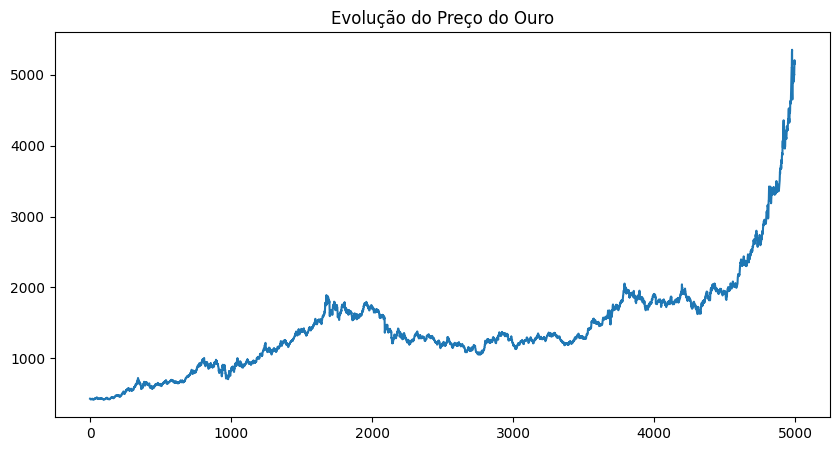

In [58]:
#Evolução do preço do ouro
df['Price'].plot(figsize=(10,5))
plt.title('Evolução do Preço do Ouro')
plt.show()

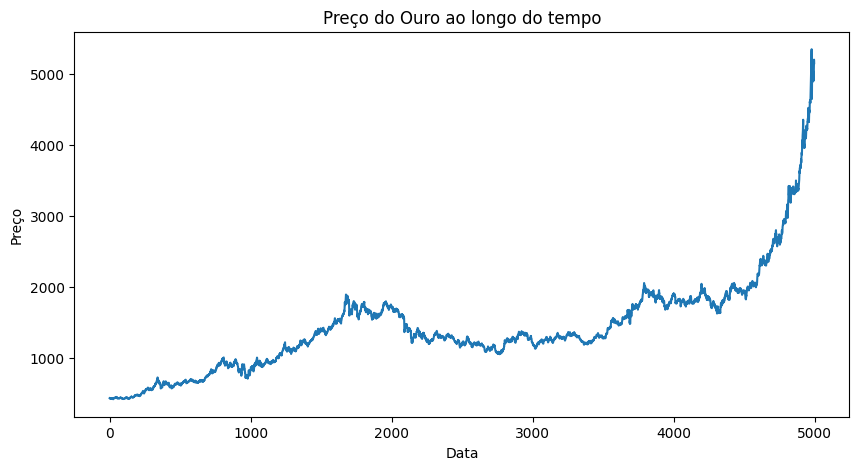

In [56]:
#Preço do ouro ao longo do tempo
df['Price'].plot(figsize=(10,5))
plt.title('Preço do Ouro ao longo do tempo')
plt.xlabel('Data')
plt.ylabel('Preço')
plt.show()

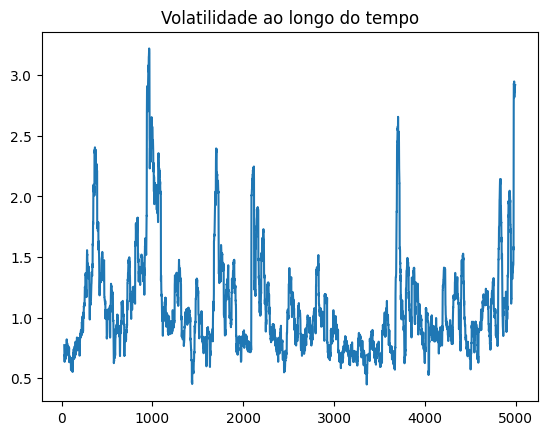

In [57]:
#Volatilidade do retorno diário ao longo do tempo
df['Change %'].rolling(30).std().plot()
plt.title('Volatilidade ao longo do tempo')
plt.show()

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de correlação
corr = df[['Price','Open','High','Low','Change %']].corr()

print("\nMatriz de Correlação:")
print(corr)


Matriz de Correlação:
             Price      Open      High       Low  Change %
Price     1.000000  0.999577  0.999729  0.999848  0.041412
Open      0.999577  1.000000  0.999833  0.999674  0.019656
High      0.999729  0.999833  1.000000  0.999579  0.029522
Low       0.999848  0.999674  0.999579  1.000000  0.033419
Change %  0.041412  0.019656  0.029522  0.033419  1.000000


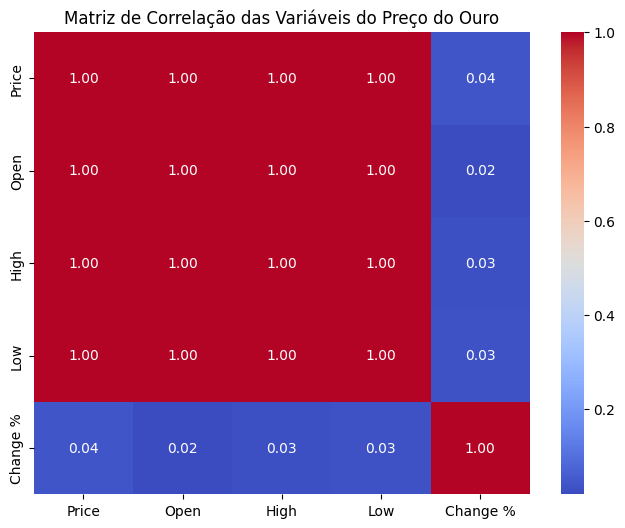

In [63]:
# Mapa de calor
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Matriz de Correlação das Variáveis do Preço do Ouro')
plt.show()

A matriz de correlação evidencia uma forte correlação entre as variáveis de preço (abertura, fechamento, máxima e mínima), o que é esperado, uma vez que representam diferentes medidas do mesmo ativo ao longo do dia.
Por outro lado, a variável de retorno percentual (Change %) apresenta baixa correlação com os preços, indicando que as variações diárias são menos previsíveis e mais independentes do nível de preço.

A alta correlação entre as variáveis de preço indica possível redundância de informação, sendo possível utilizar apenas uma delas em modelos preditivos.

## Tratamento de Valores Nulos

O dataset Iris original não possui valores nulos. No entanto, o tratamento de valores nulos é crucial e pode envolver imputação (preenchimento com média, mediana, moda) ou remoção de linhas/colunas.

In [69]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset:")
df.isnull().sum()

Valores nulos no dataset:


,0
Date,0
Price,0
Open,0
High,0
Low,0
Vol.,0
Change %,0
Log_Vol,0
Volatility,0


Não foram identificados valores nulos no dataset, indicando que não foi necessário realizar tratamentos adicionais para dados ausentes. A ausência de valores nulos contribui para maior confiabilidade das análises e simplifica o processo de modelagem.

# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

In [75]:
# Criar as variáveis
# retorno
df['Return_1d'] = df['Price'].pct_change()

# média móvel
df['MA_10'] = df['Price'].rolling(10).mean()

# volatilidade
df['Volatility_10'] = df['Return_1d'].rolling(10).std()

In [76]:
# Criar target
df['Target'] = (df['Price'].shift(-1) > df['Price']).astype(int)

In [77]:
# Remover NaNs
df = df.dropna()

In [78]:
# Separar features (X) e target (y)
X = df[['Return_1d', 'MA_10', 'Volatility_10']]
y = df['Target']

In [79]:
print(df.columns)

Index(['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %', 'Log_Vol',
       'Volatility', 'Target', 'Return_1d', 'MA_10', 'Volatility_10'],
      dtype='object')


In [80]:
# Dividir os dados em conjuntos de treino e teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (3982, 3)
Dimensões de X_test: (996, 3)
Dimensões de y_train: (3982,)
Dimensões de y_test: (996,)


Os dados foram divididos em conjuntos de treino e teste, respeitando a ordem temporal das observações. Não foi realizado embaralhamento (shuffle), garantindo que o modelo fosse treinado com dados passados e avaliado em dados futuros, evitando vazamento de informação. Essa abordagem é fundamental em séries temporais, onde a dependência temporal entre as observações deve ser preservada.

In [93]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [94]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5080321285140562
              precision    recall  f1-score   support

           0       0.46      0.48      0.47       454
           1       0.55      0.53      0.54       542

    accuracy                           0.51       996
   macro avg       0.51      0.51      0.51       996
weighted avg       0.51      0.51      0.51       996



O modelo Random Forest apresentou acurácia de aproximadamente 50,8%, muito próxima de um baseline aleatório. Esse resultado é consistente com a literatura de previsão de retornos financeiros, onde o sinal preditivo de curto prazo tende a ser fraco devido à alta eficiência e ruído do mercado. Ainda assim, observa-se leve ganho acima do acaso, sugerindo a presença de sinal informacional nas variáveis derivadas de preço. É possível tentar prever direção de preço com features simples, mas o poder preditivo é limitado e próximo do acaso.

## Normalização

A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É útil quando o algoritmo de machine learning assume que as características estão em uma escala semelhante.



In [87]:
# Normalização
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)
print(X_normalized[:5])

[[0.51347883 0.00135281 0.11620321]
 [0.54548178 0.00133984 0.11756765]
 [0.56054459 0.00133336 0.1175591 ]
 [0.50711819 0.00124476 0.13379096]
 [0.5288608  0.00100704 0.11395682]]


## Padronização

A padronização (ou Z-score scaling) transforma os dados para ter média 0 e desvio padrão 1. É útil para algoritmos que são sensíveis à escala das características, como SVMs ou redes neurais.

In [89]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)
print(X_standardized[:5])

[[-0.84146271 -1.45440149 -0.63421707]
 [-0.28853305 -1.45448811 -0.62244286]
 [-0.02828589 -1.45453143 -0.62251666]
 [-0.95135844 -1.45512336 -0.48244596]
 [-0.57570134 -1.45671148 -0.65360199]]


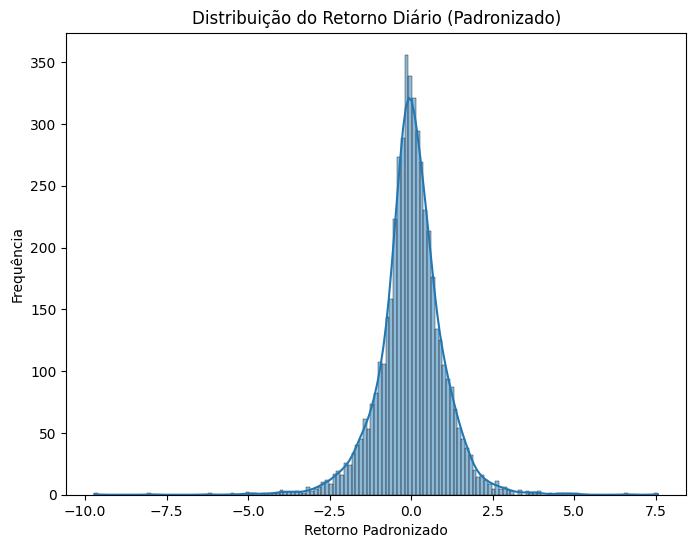

In [90]:
import pandas as pd

df_standardized_df = pd.DataFrame(X_standardized, columns=X.columns)

plt.figure(figsize=(8, 6))
sns.histplot(df_standardized_df['Return_1d'], kde=True)

plt.title('Distribuição do Retorno Diário (Padronizado)')
plt.xlabel('Retorno Padronizado')
plt.ylabel('Frequência')
plt.show()

Após a padronização, observa-se que os dados passam a apresentar distribuição centrada em torno de zero, com dispersão controlada pelo desvio padrão unitário. A padronização facilita a aplicação de modelos que assumem distribuição normal dos dados.

## Outras Transformações e Etapas de Pré-Processamento

Além das etapas realizadas, outras transformações poderiam ser aplicadas para aprimorar o modelo.
Entre elas, destaca-se a seleção de características, visando reduzir redundância entre variáveis altamente correlacionadas, como as variáveis de preço.
Também seria possível aplicar técnicas de redução de dimensionalidade, como PCA, para sintetizar a informação em menos componentes.
Adicionalmente, novas variáveis poderiam ser criadas, como indicadores técnicos (ex: médias móveis de diferentes janelas, RSI, entre outros), com o objetivo de capturar melhor padrões do mercado.
Por fim, poderia ser realizada uma validação temporal mais robusta, como validação cruzada para séries temporais.

# Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



## Hipótese 1

In [ ]:
# hipótese 1

## Hipótese 2

In [ ]:
# hipótese 2

## Hipótese 3

In [ ]:
# hipótese 3

# Conclusão

A análise e pré-processamento do dataset Iris demonstram a importância de entender a estrutura dos dados antes da modelagem. O dataset é limpo e balanceado, com características numéricas bem definidas que permitem uma clara separação entre as espécies, especialmente a Iris setosa. A análise exploratória revelou correlações importantes entre as características e a eficácia de visualizações como boxplots para distinguir as classes. As etapas de normalização e padronização são fundamentais para preparar os dados para diversos algoritmos de aprendizado de máquina, garantindo que o modelo possa aprender eficientemente com as relações presentes nos dados.

As três hipóteses levantadas foram validadas:

1.   *As diferentes espécies de Íris podem ser distinguidas com base nas medições de suas sépalas e pétalas?* Sim, dado as análises que fizemos no boxplot, observamos um comportamento muito claro e distinto.

2.   *Existe uma correlação entre comprimento da pétala e largura da pétala?* Existe forte correlação entre os atributos *petal length* e *petal width*.

3.   *A espécie Iris setosa é mais facilmente separável das outras duas espécies?* Sim, devido às suas características distintas de menor comprimento e largura da pétala.